# Script to Parcellate some Resting-State OPM-MEG Data Collected at Oxford

### This dataset contains OPM-MEG resting-state recordings collected over a 10-minute session, divided into two consecutive conditions:

#### 5 minutes — Eyes Open 👀 / 5 minutes — Eyes Closed 😌

### The data has already been pre-processed:
- Filtered 2-60Hz + Notch Filter at 50 Hz
- Bad channels and bad segments marked
- Homogenous Field Correction applied (order = 2)
- Coregistration using RHINO has been performed

In [1]:
# We start by importing the relevant packages
import osl_ephys
import numpy as np
import mne
import glob
import yaml
import os
import matplotlib.pyplot as plt
from osl_ephys.source_recon import rhino, beamforming, parcellation
import pickle
import os

# Set global font to Open Sans
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12  # Adjust font size as desired


Using matplotlib as 2D backend.


In [2]:
%matplotlib inline

## Specify Subject and subjects_dir and data_dir

In [3]:
subject      = '005'
ses          = '001'
task         = 'rest'
run          = '001'

data_dir = os.path.join(os.getcwd(),'study-FourMotorOPM')

subjects_dir = os.path.join(
    data_dir, 'BIDS', 'derivatives', 'coreg'
)
os.makedirs(subjects_dir, exist_ok=True)


## Load in the Clean Data (after pre-processing)

In [4]:
output_dir = os.path.join(data_dir,
    'BIDS', 'derivatives', 'preprocessing',
    f'sub-{subject}', f'ses-{ses}', 'meg'
)

output_file = f'sub-{subject}_ses-{ses}_task-{task}_run-{run}_clean.fif'

filename = os.path.join(output_dir, output_file)

## Setup the Parcellation

['Primary and Early Visual Cortex_rh', 'Dorsal Stream Visual Cortex_rh', 'Ventral Stream Visual Cortex_rh', 'MT+ Complex and Neighboring Visual Areas_rh', 'Superior Somatosnesory and Motor Cortex_rh', 'Inferior Somatosnesory and Motor Cortex_rh', 'Supplementory Motor Area_rh', 'Cingulate Motor Areas & Area 5_rh', 'Premotor Cortex_rh', 'Insular & Frontoparietal Operculum_rh', 'Early Auditory Cortex_rh', 'Auditory Association Cortex_rh', 'Medial Temporal Cortex_rh', 'Lateral Temporal Cortex_rh', 'Temporal-Parieto-Occipital Junction_rh', 'Medial Bank of the Intra-parietal Sulcus_rh', 'Superior Medial Parietal Cortex_rh', 'Inferior Parietal Cortex Task-Positive Network_rh', 'Inferior Parietal Cortex Task-Negative Network_rh', 'Intraparietal Sulcus & PGP_rh', 'Posterior Cingulate Cortex_rh', 'Anterior Cingulate and Medial Prefrontal Cortex_rh', 'Orbital and Polar Frontal Cortex_rh', 'Inferior Frontal Cortex_rh', 'Inferior Dorso-Lateral Prefronta Cortex_rh', 'Superior Dorso-Lateral Prefronta

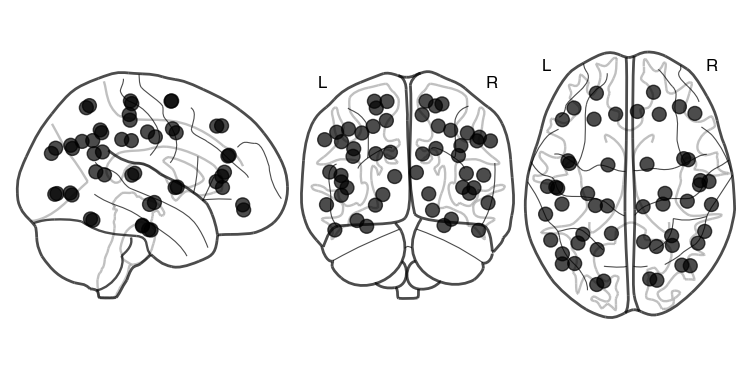

In [5]:
parcellation_fname = 'Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz'
parcellation.plot_parcellation(parcellation_fname)

# This is temporary code - Mark has updated this to include parcel names in
labels_fname       = 'Labels.p'

with open(labels_fname, 'rb') as f:
    labels = pickle.load(f)

print(labels)


## Read the clean data

In [6]:
# Load raw data
clean = mne.io.read_raw_fif(filename, preload=True)

Opening raw data file /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-005/ses-001/meg/sub-005_ses-001_task-rest_run-001_clean.fif...
    Read a total of 8 projection items:
        HFC: l=1 m=-1 (1 x 174) active
        HFC: l=1 m=0 (1 x 174) active
        HFC: l=1 m=1 (1 x 174) active
        HFC: l=2 m=-2 (1 x 174) active
        HFC: l=2 m=-1 (1 x 174) active
        HFC: l=2 m=0 (1 x 174) active
        HFC: l=2 m=1 (1 x 174) active
        HFC: l=2 m=2 (1 x 174) active
    Range : 0 ... 193381 =      0.000 ...   644.603 secs
Ready.
Reading 0 ... 193381  =      0.000 ...   644.603 secs...


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_1511/4274689959.py:2: RuntimeWarning: This filename (/Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/preprocessing/sub-005/ses-001/meg/sub-005_ses-001_task-rest_run-001_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  clean = mne.io.read_raw_fif(filename, preload=True)


## Compute the rank

Using up to 3223 segments
Number of samples used : 192060
[done]
Computing rank from covariance with rank=None
    Using tolerance 1.7e-13 (2.2e-16 eps * 174 dim * 4.4  max singular value)
    Estimated rank (mag): 163
    MAG: rank 163 computed from 174 data channels with 0 projectors


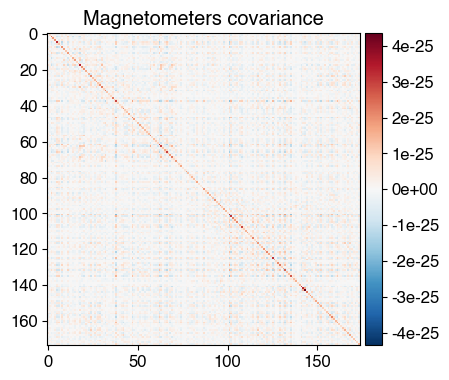

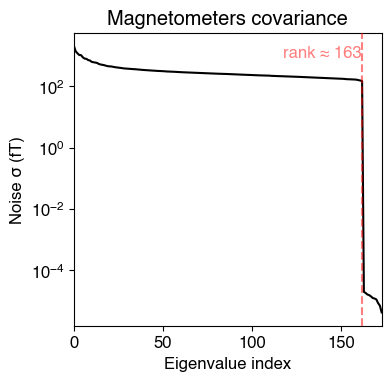

Computing rank from covariance with rank=None
    Using tolerance 1.7e-13 (2.2e-16 eps * 174 dim * 4.4  max singular value)
    Estimated rank (mag): 163
    MAG: rank 163 computed from 174 data channels with 8 projectors

Estimated rank from covariance:
mag: 163


In [7]:
# Compute and plot the rank
cov_all = mne.compute_raw_covariance(clean)

# Plot the covariance matrix
fig_cov = mne.viz.plot_cov(cov_all, clean.info)

# Compute the rank of the covariance matrix
rank = mne.compute_rank(cov_all, info=clean.info)

print("\nEstimated rank from covariance:")
for key, value in rank.items():
    print(f"{key}: {value}")

# I manually adjust this value down by 3 for safety when we invert the covariance matrix during beamforming
rank['mag'] = rank['mag'] - 3


## Beamform

In [8]:
# Make LCMV beamformer filters
filters = beamforming.make_lcmv(
    subjects_dir,
    subject,
    clean,
    {'mag'},
    pick_ori="max-power-pre-weight-norm",
    reduce_rank=True,
    rank=rank,
)
print("Applying beamformer spatial filters")

*** RUNNING OSL MAKE LCMV ***
Reading forward solution from /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/coreg/005/rhino/model-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (2835 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
Using up to 3223 segments
Number of samples used : 192060
[done]
variance for chantype mag is 1.5425763767894431e-25
Computing rank from covariance with rank={'mag': 160}
Computing rank from covariance with rank='info'
    MAG: rank 166 after 8 projectors applied to 174 channels
Making LCMV beamformer with data cov rank {'mag': 160}
Making LCMV beamformer with noise cov rank {'mag': 166}
Computing inverse operator with 174 channels.
    174 out of 192 channels remain after picking
Selected 174 channels
Whiten

In [9]:
# Apply beamformer, keep bad segments for now
stc = beamforming.apply_lcmv(clean, filters, reject_by_annotation=None)

beamforming.apply_lcmv


## Transform timeseries to MNI space


In [10]:
recon_timeseries_mni, _, recon_coords_mni, _ = beamforming.transform_recon_timeseries(
    subjects_dir,
    subject,
    recon_timeseries=stc.data,
    reference_brain="mni"
)
print("Dimensions of reconstructed timeseries in MNI space (dipoles x tpts):", recon_timeseries_mni.shape)

Reading forward solution from /Users/robertseymour/data/study-OPM_training_fresh_test/study-FourMotorOPM/BIDS/derivatives/coreg/005/rhino/model-fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (2835 sources, 192 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame
spatial_resolution = 8 mm
Dimensions of reconstructed timeseries in MNI space (dipoles x tpts): (4633, 193382)


## Parcellate source time series into atlas-defined brain regions


In [11]:
parcel_ts, _, _ = parcellation.vol_parcellate_timeseries(
    parcellation_fname,   # atlas file (e.g. .nii.gz) defining parcels in MNI space
    recon_timeseries_mni, # source-level time series (time x vertices)
    recon_coords_mni,     # MNI coordinates of each vertex
    "spatial_basis",      # method: project using spatial basis maps
    None                  # no extra options
)

gridstep = 8 mm


### Annotations

The conversion to MNE data structure automatically excludes bad segments (turns those segments to NaN or 0). To keep all data but mark the data as 'bad' we do some jiggery pokery to remove annotations, convert the parcellated time-series to an MNE structure then add the annotations back in.


In [12]:
# Copy and remove annotations
annotations_copy = clean.annotations.copy()
clean.set_annotations(None)

# Convert parcellated timeseries to MNE Raw
parc_raw = parcellation.convert2mne_raw(parcel_ts, clean, labels)

# Restore annotations safely
try:
    parc_raw.set_annotations(annotations_copy)
except ValueError:
    print("Warning: could not restore annotations (time mismatch)")

Creating RawArray with float64 data, n_channels=52, n_times=193382
    Range : 0 ... 193381 =      0.000 ...   644.603 secs
Ready.


In [13]:
# Set all channels to magnetometers
parc_raw.set_channel_types({ch: 'mag' for ch in parc_raw.info['ch_names']})

/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_1511/3882728402.py:2: RuntimeWarning: The unit for channel(s) Anterior Cingulate and Medial Prefrontal Cortex_lh, Anterior Cingulate and Medial Prefrontal Cortex_rh, Auditory Association Cortex_lh, Auditory Association Cortex_rh, Cingulate Motor Areas & Area 5_lh, Cingulate Motor Areas & Area 5_rh, Dorsal Stream Visual Cortex_lh, Dorsal Stream Visual Cortex_rh, Early Auditory Cortex_lh, Early Auditory Cortex_rh, Inferior Dorso-Lateral Prefronta Cortex_lh, Inferior Dorso-Lateral Prefronta Cortex_rh, Inferior Frontal Cortex_lh, Inferior Frontal Cortex_rh, Inferior Parietal Cortex Task-Negative Network_lh, Inferior Parietal Cortex Task-Negative Network_rh, Inferior Parietal Cortex Task-Positive Network_lh, Inferior Parietal Cortex Task-Positive Network_rh, Inferior Somatosnesory and Motor Cortex_lh, Inferior Somatosnesory and Motor Cortex_rh, Insular & Frontoparietal Operculum_lh, Insular & Frontoparietal Operculum_rh, Intrapariet

<RawArray | 52 x 193382 (644.6 s), ~76.8 MiB, data loaded>

### Plot

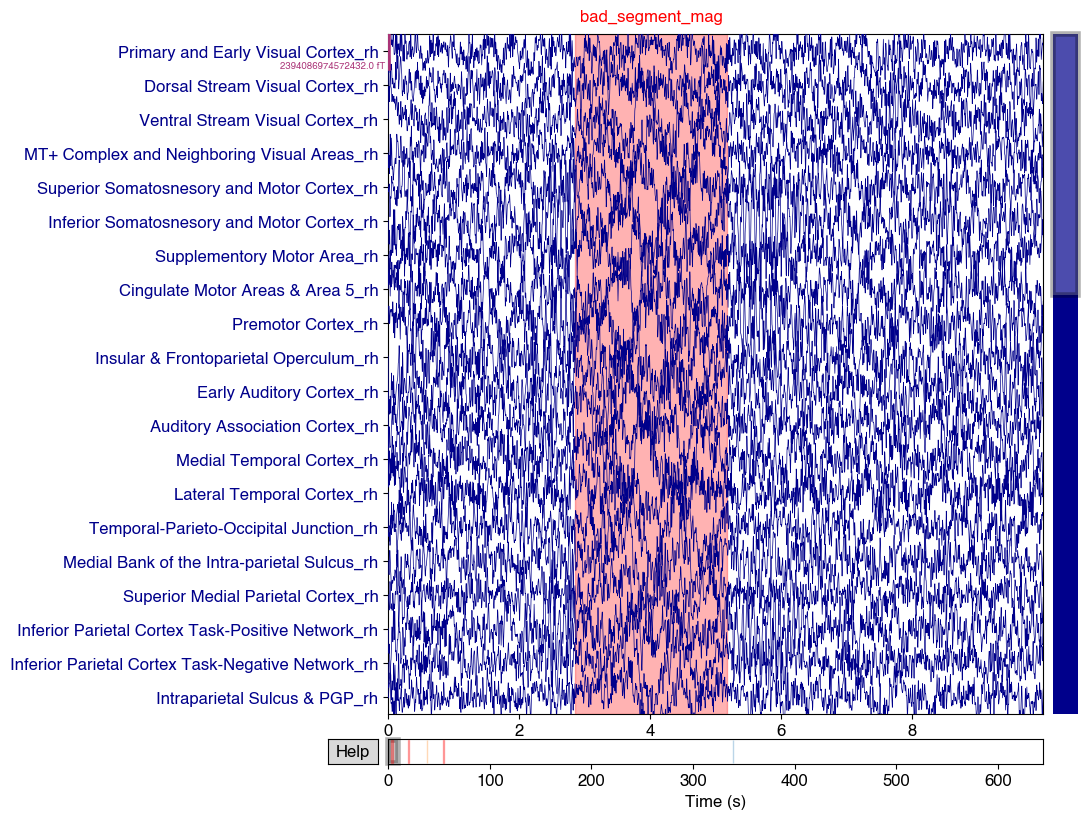

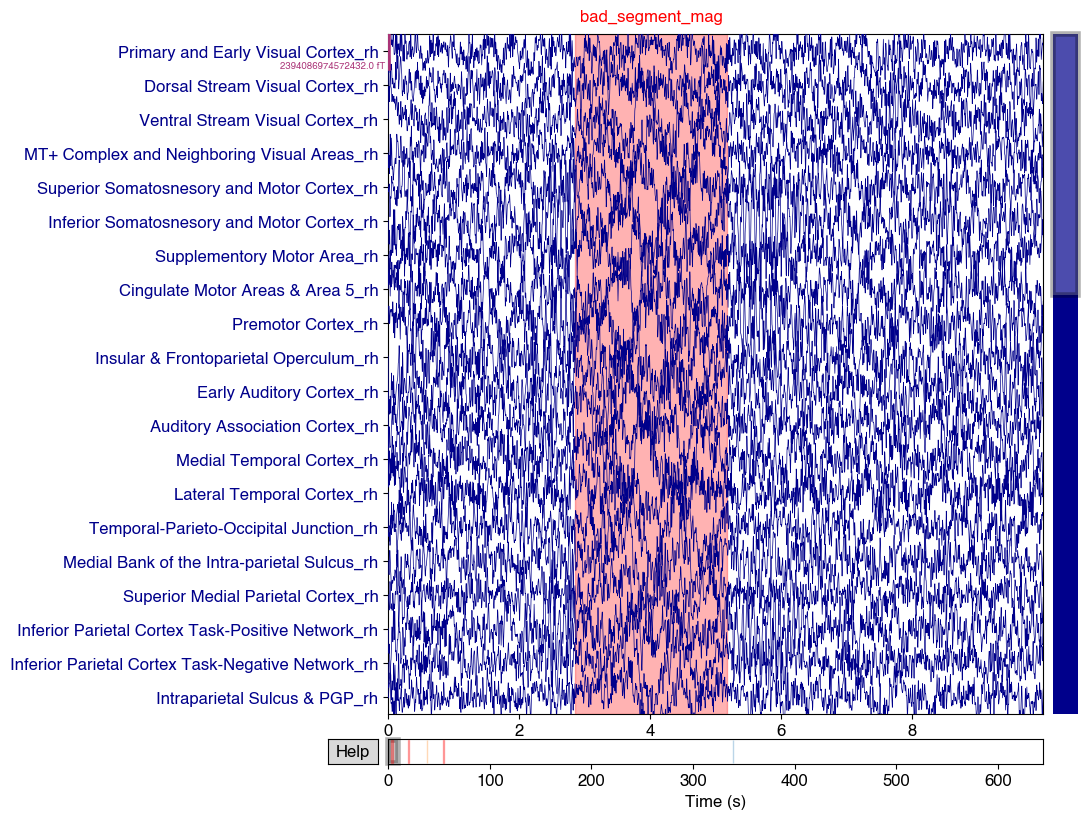

In [14]:
parc_raw.plot(scalings='auto')

## Post-Processing

Now that we have the parcellated data we can analyse it! Here I am computing spectral power in the alpha band (8-12 Hz) and comparing eyes open versus eyes closed epochs

In [15]:
# Load Events File Computed Earlier
output_dir = (
    f"{data_dir}/BIDS/derivatives/event/"
    f"sub-{subject}/ses-{ses}/meg"
)

output_file = f"sub-{subject}_ses-{ses}_task-{task}_events.npy"

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Load the events file
events = np.load(os.path.join(output_dir, output_file))

### Cut into 2x 300s chunks

In [16]:
# Define event codes for each condition
event_id = {'eyes_open': 2, 'eyes_closed': 1}

# Sampling frequency of the data
sfreq = parc_raw.info['sfreq']

# --- Eyes open (code 2) ---
# Find the sample index of the 'eyes open' event
eyes_open_idx = events[events[:, 2] == event_id['eyes_open'], 0]

# Check there is exactly one such event
if len(eyes_open_idx) != 1:
    raise ValueError(f"Expected 1 eyes-open event, found {len(eyes_open_idx)}")

# Convert event sample index to start/end times (seconds); extract 300 s segment
tmin, tmax = eyes_open_idx[0] / sfreq, eyes_open_idx[0] / sfreq + 300

# Copy raw data and crop to the eyes-open segment
eyes_open = parc_raw.copy().crop(tmin=tmin, tmax=tmax)

# --- Eyes closed (code 1) ---
# Find the sample index of the 'eyes closed' event
eyes_closed_idx = events[events[:, 2] == event_id['eyes_closed'], 0]

# Check there is exactly one such event
if len(eyes_closed_idx) != 1:
    raise ValueError(f"Expected 1 eyes-closed event, found {len(eyes_closed_idx)}")

# Convert event sample index to start/end times (seconds); extract 300 s segment
tmin, tmax = eyes_closed_idx[0] / sfreq, eyes_closed_idx[0] / sfreq + 300

# Copy raw data and crop to the eyes-closed segment
eyes_closed = parc_raw.copy().crop(tmin=tmin, tmax=tmax)


### Plot

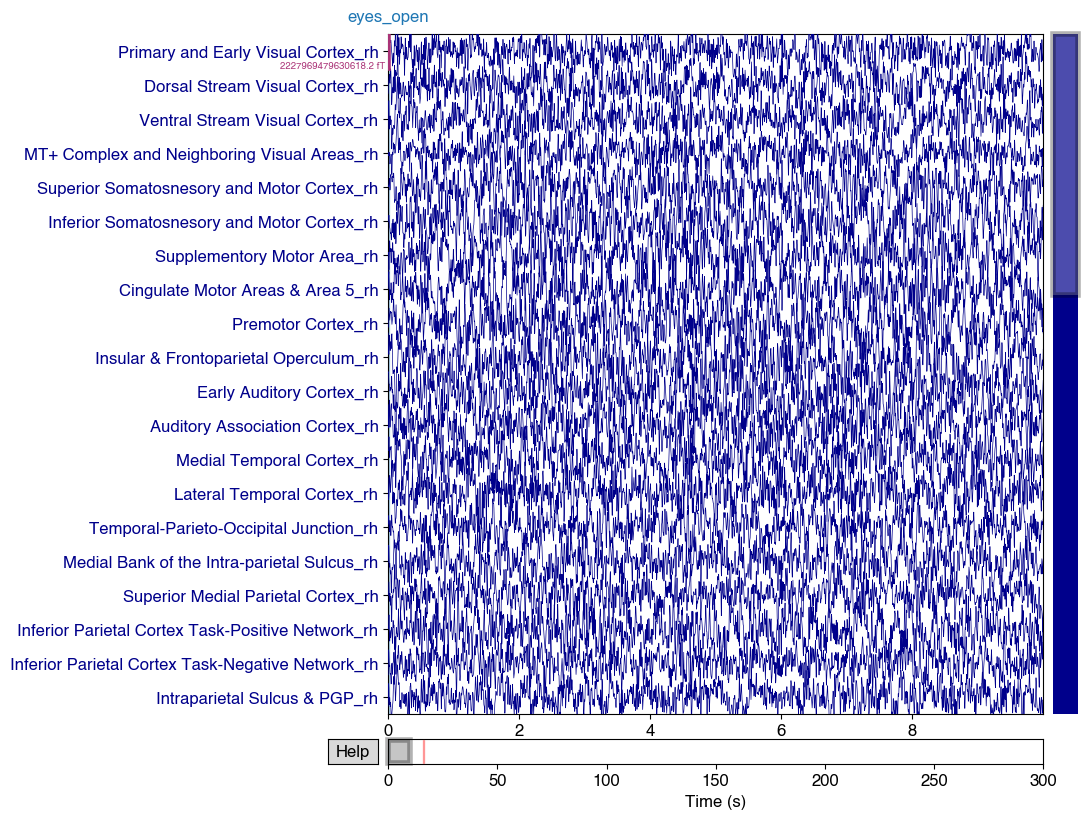

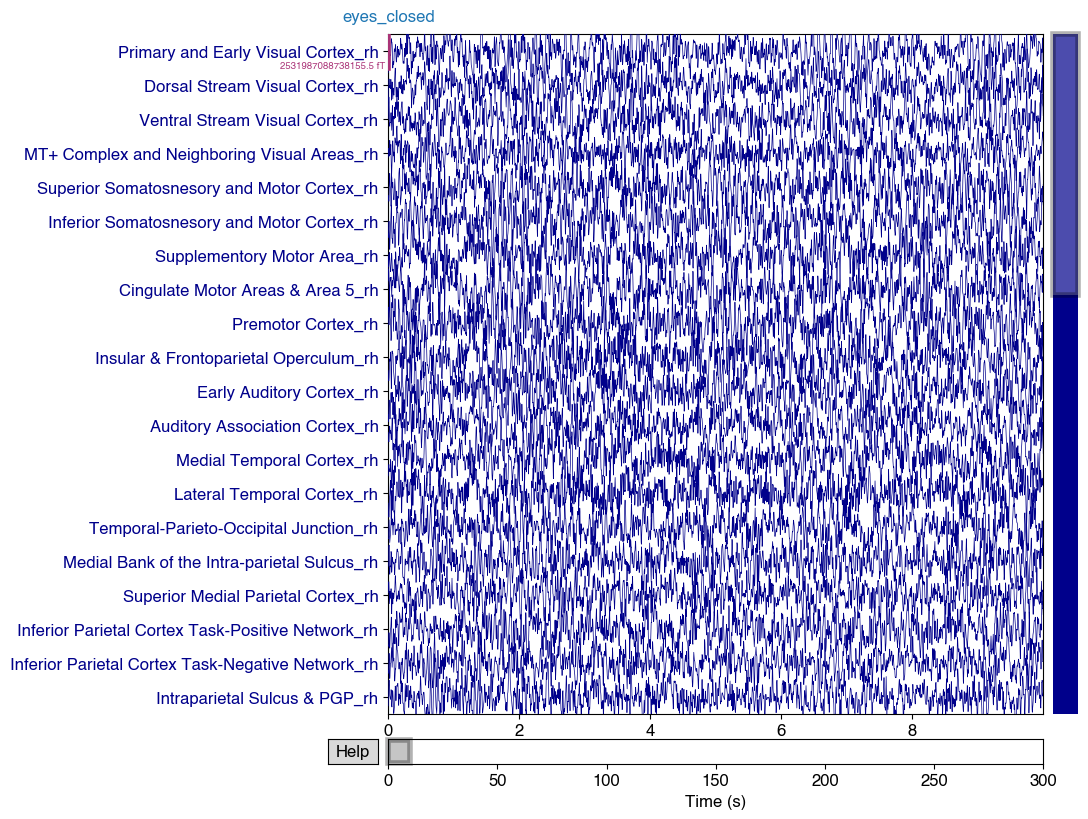

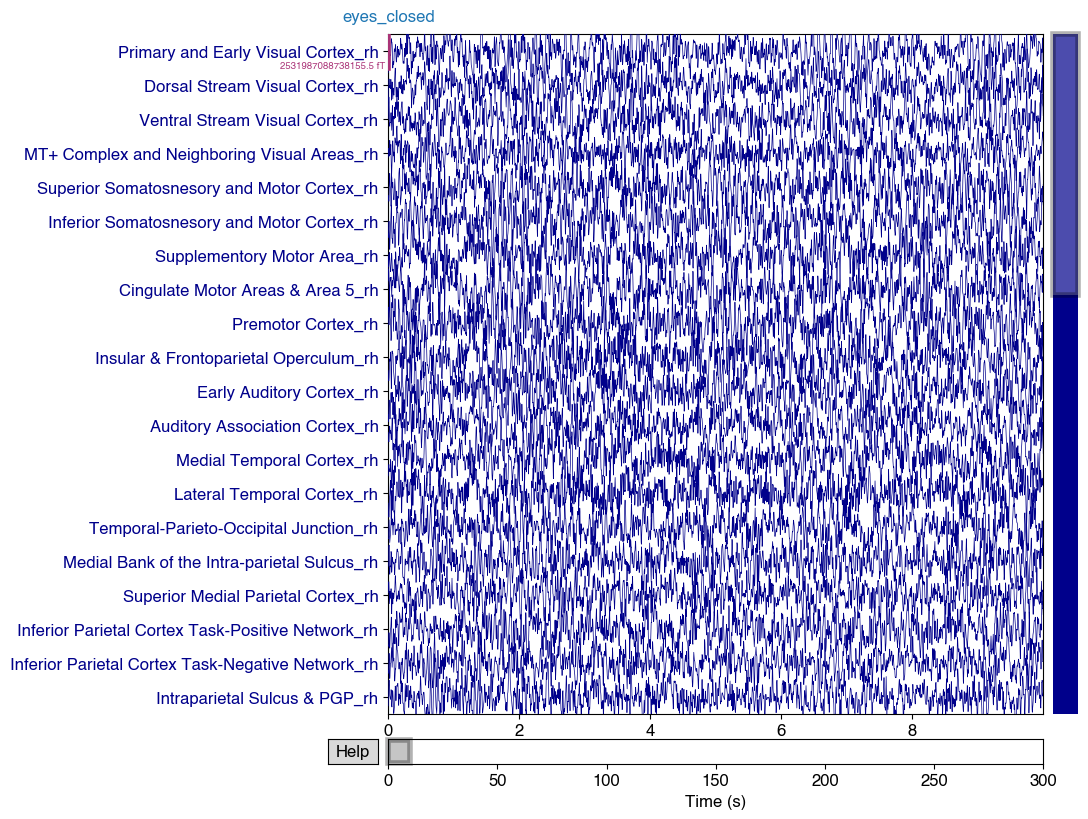

In [17]:
eyes_open.plot(scalings='auto', duration=10, title="Eyes Open")
eyes_closed.plot(scalings='auto', duration=10, title="Eyes Closed")

### Compute PSD

Setting 186 of 90001 (0.21%) samples to NaN, retaining 89815 (99.79%) samples.
Effective window size : 3.333 (s)
Effective window size : 3.333 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_1511/3972546491.py:11: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psds_open.plot(axes=axes[0], show=False)
/var/folders/lc/2w90j0s17cx3s8fl2m6h2gz80000gn/T/ipykernel_1511/3972546491.py:14: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psds_closed.plot(axes=axes[1], show=False)


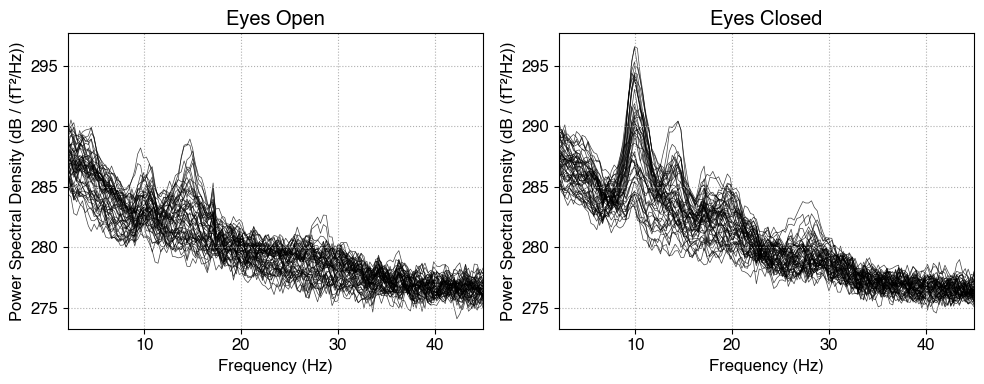

In [18]:
import matplotlib.pyplot as plt

# Compute PSDs
psds_open = eyes_open.compute_psd(method='welch', fmin=2, fmax=45, n_fft=1000, picks='mag')
psds_closed = eyes_closed.compute_psd(method='welch', fmin=2, fmax=45, n_fft=1000, picks='mag')

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot PSDs using built-in method
psds_open.plot(axes=axes[0], show=False)
axes[0].set_title('Eyes Open')

psds_closed.plot(axes=axes[1], show=False)
axes[1].set_title('Eyes Closed')

# After plotting, read the y-limits from both subplots
ymin_open, ymax_open = axes[0].get_ylim()
ymin_closed, ymax_closed = axes[1].get_ylim()

# Compute global y-limits
ymin = min(ymin_open, ymin_closed)
ymax = max(ymax_open, ymax_closed)

# Set both subplots to the same y-limits
axes[0].set_ylim(ymin, ymax)
axes[1].set_ylim(ymin, ymax)

# Optional: add shared axis labels
for ax in axes:
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power Spectral Density (dB / (fT²/Hz))')

plt.tight_layout()
plt.show()


### Segment the data into 2s chunks

In [19]:
import mne
import numpy as np

def segment_epoched(epochs, duration=2):
    """
    Re-epoch the given epochs into fixed-length segments.

    Parameters:
    epochs : mne.Epochs
        The original epochs to be re-epoched.
    duration : float
        The duration of each segment in seconds.

    Returns:
    mne.Epochs
        The re-epoched data.
    """
    # Get the data and info from the original epochs
    data = epochs.get_data()
    info = epochs.info.copy()

    # Create a new RawArray from the epoched data
    raw_new = mne.io.RawArray(np.squeeze(data), info)

    # Re-epoch into fixed-length segments
    fixed_length_epochs = mne.make_fixed_length_epochs(raw_new, duration=duration, preload=True)

    return fixed_length_epochs

eyes_open_segmented     = segment_epoched(eyes_open, duration=2)
eyes_closed_segmented   = segment_epoched(eyes_closed, duration=2)


Creating RawArray with float64 data, n_channels=52, n_times=90001


    Range : 0 ... 90000 =      0.000 ...   300.000 secs
Ready.
Not setting metadata
150 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 150 events and 600 original time points ...
0 bad epochs dropped
Creating RawArray with float64 data, n_channels=52, n_times=90001
    Range : 0 ... 90000 =      0.000 ...   300.000 secs
Ready.
Not setting metadata
150 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 150 events and 600 original time points ...
0 bad epochs dropped


### Compute Time-Frequency Respresentations

In [20]:
# Define frequencies of interest and number of cycles for Morlet wavelets
freqs = np.arange(8, 13, 1)  # 8-12 Hz
n_cycles = freqs / 3.  # Different number of cycles per frequency

# Compute TFR using Morlet wavelets
tfr_open   = mne.time_frequency.tfr_morlet(eyes_open_segmented, freqs=freqs, n_cycles=n_cycles, use_fft=True, return_itc=False, decim=3, n_jobs=1)
tfr_closed = mne.time_frequency.tfr_morlet(eyes_closed_segmented, freqs=freqs, n_cycles=n_cycles, use_fft=True, return_itc=False, decim=3, n_jobs=1)

# Average power in the alpha band (8-12 Hz) over time and frequency
alpha_power_open = tfr_open.data.mean(axis=2).mean(axis=1)
alpha_power_closed = tfr_closed.data.mean(axis=2).mean(axis=1)

# Compute the difference (dB) in alpha power
alpha_power_diff = 20*(np.log(alpha_power_open/alpha_power_closed))

NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


### Plot by interpolating the data onto a whole-brain map

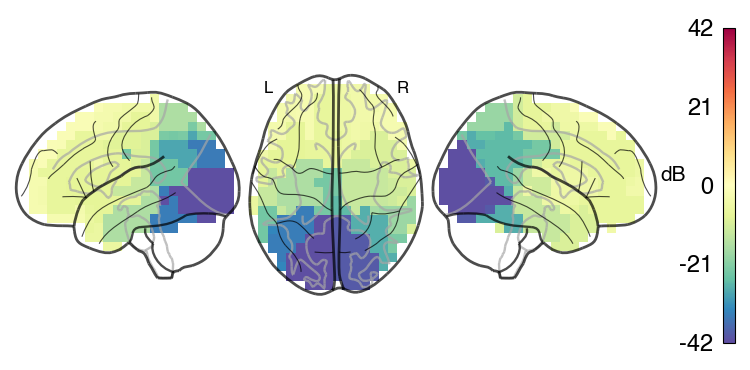

In [21]:
from osl_ephys.source_recon.parcellation import parcel_vector_to_voxel_grid, find_file
import nibabel as nib
from nilearn import plotting

# Template brain mask used to define the voxel grid and spatial metadata
mask_fname = "MNI152_T1_8mm_brain.nii.gz"

# Parcellation in MNI space at 8 mm resolution (binary parcels)
parcellation_fname = "Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz"

# Convert parcel-wise values to a voxel-wise 3D grid
# alpha_power_diff should be a 1D array with one value per parcel
power_map = parcel_vector_to_voxel_grid(
    mask_fname,
    parcellation_fname,
    alpha_power_diff,
)

# Resolve the mask filename to its full path on disk
mask_file = find_file(mask_fname, freesurfer=False)

# Load the mask NIfTI so we can reuse its affine and header
mask = nib.load(mask_file)

# Wrap the voxel grid as a NIfTI image for nilearn plotting
nii = nib.Nifti1Image(power_map, mask.affine, mask.header)

# Compute symmetric color limits so positive and negative effects are comparable
abs_max_value = np.max(np.abs(power_map))

# Plot a glass brain showing signed values (not absolute)
display = plotting.plot_glass_brain(
    nii,
    title="",
    threshold=0,
    colorbar=True,
    cmap="Spectral_r",
    plot_abs=False,
    vmin=-abs_max_value,
    vmax=abs_max_value,
    display_mode="lzr",
)

# Customize the colorbar (label in dB, larger tick labels)
# Note: display._cbar is a private attribute and may change in future nilearn versions
cbar = display._cbar
cbar.set_label("dB", fontsize=15)
cbar.ax.tick_params(labelsize=17)
cbar.ax.yaxis.set_label_position("left")
cbar.ax.yaxis.label.set_rotation(0)

# Render the figure
plt.show()